In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

In [2]:
df = pd.read_csv("xAPI-Edu-Data.csv")
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [3]:
print("Shape before cleaning:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print(df["Class"].value_counts())

Shape before cleaning: (480, 17)
Duplicate rows: 2
Shape after removing duplicates: (478, 17)
Class
M    211
H    142
L    125
Name: count, dtype: int64


In [4]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X_encoded = pd.get_dummies(X, drop_first=False)

print("Encoded feature matrix shape:", X_encoded.shape)
X_encoded.head()

Feature matrix shape: (478, 16)
Target shape: (478,)
Encoded feature matrix shape: (478, 72)


,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_F,gender_M,NationalITy_Egypt,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,...,Semester_F,Semester_S,Relation_Father,Relation_Mum,ParentAnsweringSurvey_No,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Bad,ParentschoolSatisfaction_Good,StudentAbsenceDays_Above-7,StudentAbsenceDays_Under-7
0,15,16,2,20,False,True,False,False,False,False,...,True,False,True,False,False,True,False,True,False,True
1,20,20,3,25,False,True,False,False,False,False,...,True,False,True,False,False,True,False,True,False,True
2,10,7,0,30,False,True,False,False,False,False,...,True,False,True,False,True,False,True,False,True,False
3,30,25,5,35,False,True,False,False,False,False,...,True,False,True,False,True,False,True,False,True,False
4,40,50,12,50,False,True,False,False,False,False,...,True,False,True,False,True,False,True,False,True,False


In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded class labels:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Encoded class labels: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}
X_train shape: (382, 72)
X_test shape: (96, 72)
y_train shape: (382,)
y_test shape: (96,)


In [6]:
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression Weighted F1:", lr_f1)

Logistic Regression Accuracy: 0.7291666666666666
Logistic Regression Weighted F1: 0.7277361316314256


In [7]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

           H       0.75      0.72      0.74        29
           L       0.75      0.84      0.79        25
           M       0.70      0.67      0.68        42

    accuracy                           0.73        96
   macro avg       0.73      0.74      0.74        96
weighted avg       0.73      0.73      0.73        96



In [8]:
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree, average="weighted")

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Weighted F1:", tree_f1)

Decision Tree Accuracy: 0.7083333333333334
Decision Tree Weighted F1: 0.7083400943842711


In [9]:
print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree, target_names=label_encoder.classes_))

Classification Report - Decision Tree
              precision    recall  f1-score   support

           H       0.80      0.69      0.74        29
           L       0.67      0.80      0.73        25
           M       0.68      0.67      0.67        42

    accuracy                           0.71        96
   macro avg       0.72      0.72      0.71        96
weighted avg       0.71      0.71      0.71        96



In [10]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=8
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Weighted F1:", rf_f1)

Random Forest Accuracy: 0.8020833333333334
Random Forest Weighted F1: 0.8020596835225318


In [11]:
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Classification Report - Random Forest
              precision    recall  f1-score   support

           H       0.79      0.76      0.77        29
           L       0.88      0.88      0.88        25
           M       0.77      0.79      0.78        42

    accuracy                           0.80        96
   macro avg       0.81      0.81      0.81        96
weighted avg       0.80      0.80      0.80        96



In [12]:
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [lr_accuracy, tree_accuracy, rf_accuracy],
    "Weighted F1 Score": [lr_f1, tree_f1, rf_f1]
})

results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy,Weighted F1 Score
2,Random Forest,0.802083,0.802060
0,Logistic Regression,0.729167,0.727736
1,Decision Tree,0.708333,0.708340


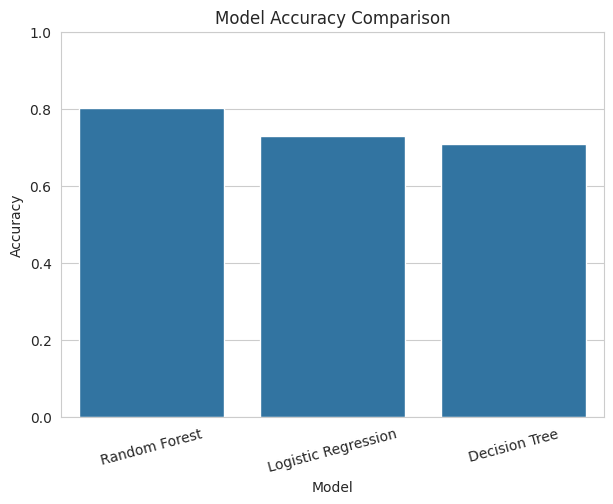

In [13]:
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

In [14]:
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
1,VisITedResources,0.136572
0,raisedhands,0.118807
70,StudentAbsenceDays_Above-7,0.092577
2,AnnouncementsView,0.087341
71,StudentAbsenceDays_Under-7,0.084902
3,Discussion,0.063396
66,ParentAnsweringSurvey_No,0.029910
64,Relation_Father,0.028269
67,ParentAnsweringSurvey_Yes,0.026474
65,Relation_Mum,0.025554


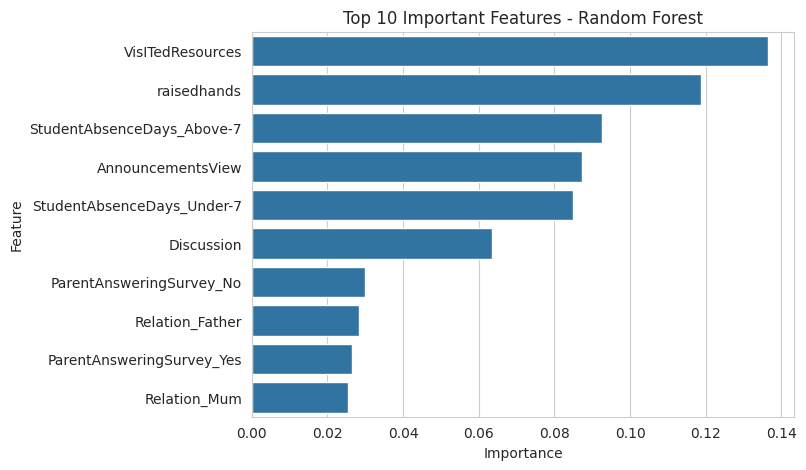

In [15]:
top_features = feature_importance.head(10)

sns.barplot(data=top_features, x="Importance", y="Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.show()

In [16]:
best_model_row = results_df.iloc[0]

print("Best Model:", best_model_row["Model"])
print("Best Accuracy:", best_model_row["Accuracy"])
print("Best Weighted F1 Score:", best_model_row["Weighted F1 Score"])
print("Machine learning stage completed successfully.")

Best Model: Random Forest
Best Accuracy: 0.8020833333333334
Best Weighted F1 Score: 0.8020596835225318
Machine learning stage completed successfully.
